In [1]:
# Basic and plotting packages
suppressMessages( library(kableExtra) )
suppressMessages( library(ggplot2) )
suppressMessages( library(plotly) )
suppressMessages( library(cowplot) )
suppressMessages( library(latex2exp) )
t = theme(plot.title = element_text(size=26, hjust=0.5),
          axis.title = element_text(size=20),
          axis.text = element_text(size=16),
          legend.title = element_text(size = 20),
          legend.text = element_text(size = 16),
          plot.subtitle = element_text(size = 18, face="bold"))
theme_set(theme_minimal()+t)
options(repr.plot.width=16, repr.plot.height=6)

suppressMessages( library(gtools) )

# Utils packages
suppressMessages( library(dplyr) ) # Pipeline
suppressMessages( library(snow) ) # Parallel apply, sapply, lapply
suppressMessages( library(pbapply) ) # Progressbar apply, sapply, lapply
suppressMessages( library(pbmcapply) ) # Progress bar in for loop (needs to be installed manually: https://cran.r-project.org/web/packages/pbmcapply/index.html)

suppressMessages( library(TSA) )
suppressMessages( library(rugarch) )

suppressMessages( library(mvtnorm) )
suppressMessages( library(tmvmixnorm) )
suppressMessages( library(truncnorm) )

suppressMessages( library(extRemes) )

# Integrate R with C++
suppressMessages( library(Rcpp) )
# Compile the c++ codes
Sys.setenv(PKG_LIBS = "-lmpfr -lgmp -lquadmath")
sourceCpp("../divergence_parallel.cpp")
Sys.setenv(PKG_LIBS = "-lmpfr -lgmp -lquadmath", PKG_CXXFLAGS="-O3 -ffast-math")
sourceCpp("posterior_sampler_eigen.cpp")

# Load Simulation Files - GARCH(1,1)

In [2]:
files <- paste0("Simulations2/", c("sim4.1.RData", "sim4.2.RData", "sim4.3.RData", "sim4.4.RData", "sim4.5.RData",
                                   "sim4.6.RData", "sim4.7.RData", "sim4.8.RData", "sim4.9.RData", "sim4.10.RData",
                                   "sim4.11.RData", "sim4.12.RData", "sim4.13.RData", "sim4.14.RData", "sim4.15.RData",
                                   "sim4.16.RData", "sim4.17.RData", "sim4.18.RData", "sim4.19.RData", "sim4.20.RData"
                                   ))
for(file in files){
    load(file)
}

In [3]:
# Given a table of divergence metrics, take the maximum for each column
get_max_div <- function(div_table){
    apply(div_table, 2, max)
}

# Given a list of divergence tables, take the maximum in each column and join them in the same table
list_max_div <- function(div_tables){
    max_table <- sapply(div_tables, function(div_table){
        get_max_div(div_table)
    })
    col_names <- rownames(max_table)
    max_table <- t(max_table)
    colnames(max_table) <- col_names
    max_table
}

In [4]:
max_div <- list_max_div(sim4.1_1000$divergences)
max_div_KL <- max_div[,1]
max_div_KL_rev <- max_div[,2]
max_div_J <- max_div[,3]
max_div_chi2 <- max_div[,4]
max_div_chi2_rev <- max_div[,5]
max_div_chi2_sym <- max_div[,6]
max_div_L1 <- max_div[,7]
max_div_H <- max_div[,8]
max_div_JS <- max_div[,9]


	Asymptotic one-sample Kolmogorov-Smirnov test

data:  max_div_metric
D = 0.033925, p-value = 0.9358
alternative hypothesis: two-sided



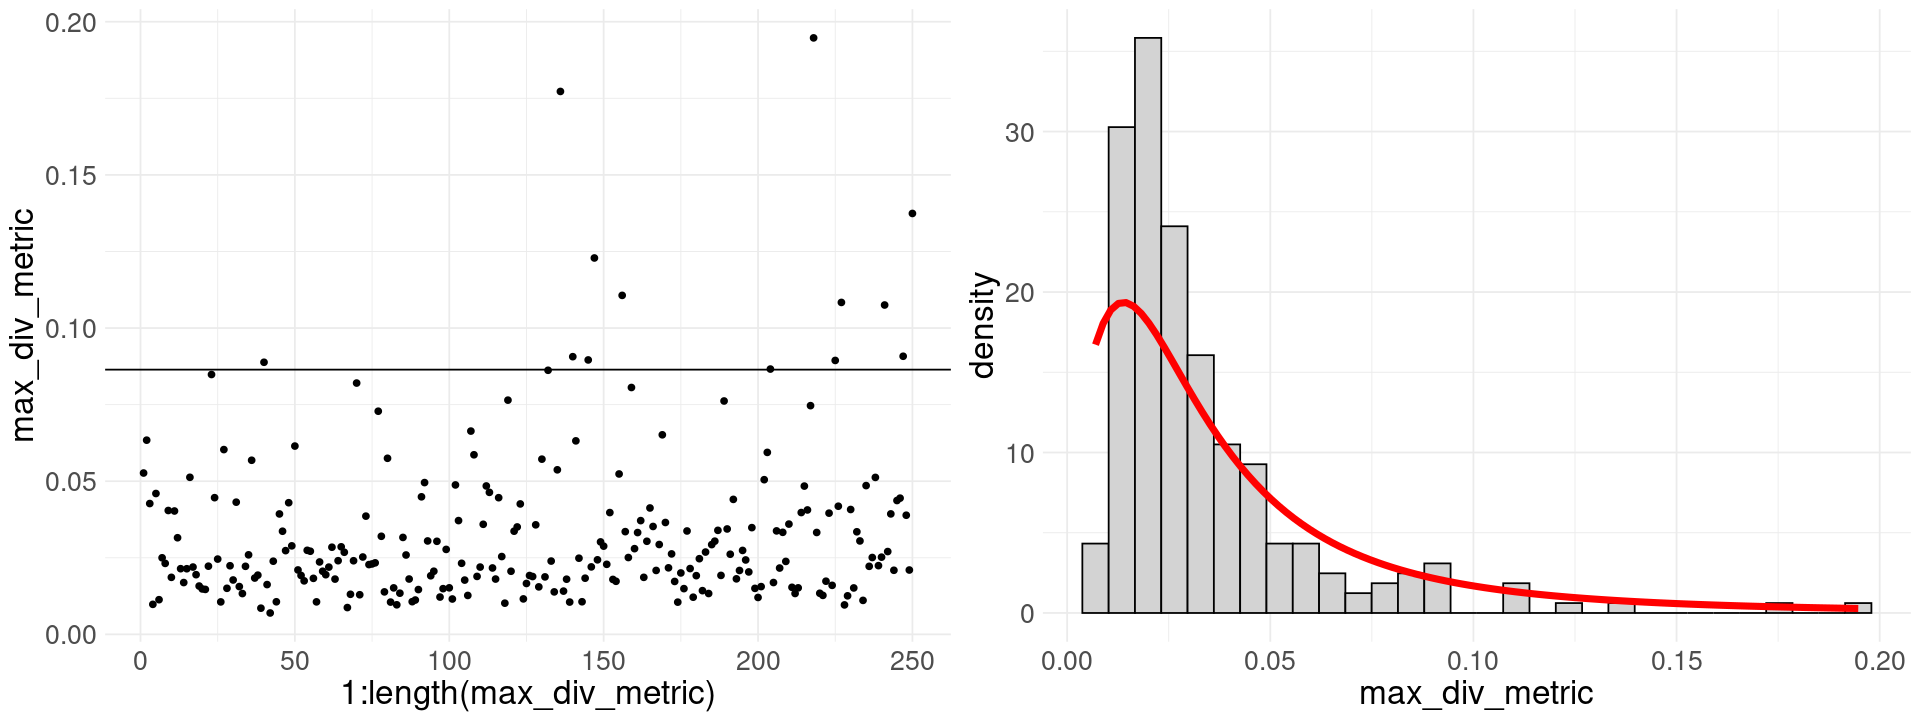

In [5]:
max_div_metric <- max_div_H

fit <- fevd(max_div_metric, type = "GEV", method = "MLE")
params <- fit$results$par
ks_result <- ks.test(max_div_metric, "pevd", 
                     loc = params["location"], 
                     scale = params["scale"], 
                     shape = params["shape"], 
                     type = "GEV")
print(ks_result)

scatter_max_div <- ggplot()+
    geom_point(aes(x = 1:length(max_div_metric), y = max_div_metric))+
    geom_hline(aes(yintercept = quantile(max_div_metric, 0.95)))
hist_max_div <- ggplot()+
    geom_histogram(aes(x = max_div_metric, y = after_stat(density)), bins = 30, color = "black", fill = "lightgray")+
    stat_function(fun = devd, args = list("loc" = fit$results$par[1], "scale" = fit$results$par[1], "shape" = fit$results$par[3]), color = "red", linewidth = 2 )

options(repr.plot.width = 16, repr.plot.height = 6)
plot_grid(scatter_max_div, hist_max_div)

All metrics can be fitted satisfactorily by a GEVD. To see that, we can perform KS the test for each divergence metric maximum, which is done in the next cell.

In [6]:
alpha <- 0.05
ks_tests <- lapply( list(max_div_KL, max_div_KL_rev, max_div_J, max_div_chi2, max_div_chi2_rev, max_div_chi2_sym, max_div_L1, max_div_H, max_div_JS), function(x){
    fit <- fevd(x, type = "GEV", method = "MLE")
    params <- fit$results$par
    ks_result <- ks.test(x, "pevd", 
                         loc = params["location"], 
                         scale = params["scale"], 
                         shape = params["shape"], 
                         type = "GEV")
    if(ks_result$p.value < alpha)
        return(1)
    else
        return(0)
}) %>% unlist()
print(paste0("In total, ", sum(ks_tests), " KS tests were rejected."))

[1] "In total, 0 KS tests were rejected."


# GEV parameters regression

In [7]:
max_div4.1 <- list_max_div(sim4.1_1000$divergences)
max_div4.2 <- list_max_div(sim4.2_1000$divergences)
max_div4.3 <- list_max_div(sim4.3_1000$divergences)
max_div4.4 <- list_max_div(sim4.4_1000$divergences)
max_div4.5 <- list_max_div(sim4.5_1000$divergences)
max_div4.6 <- list_max_div(sim4.6_1000$divergences)
max_div4.7 <- list_max_div(sim4.7_1000$divergences)
max_div4.8 <- list_max_div(sim4.8_1000$divergences)
max_div4.9 <- list_max_div(sim4.9_1000$divergences)
max_div4.10 <- list_max_div(sim4.10_1000$divergences)
max_div4.11 <- list_max_div(sim4.11_1000$divergences)
max_div4.12 <- list_max_div(sim4.12_1000$divergences)
max_div4.13 <- list_max_div(sim4.13_1000$divergences)
max_div4.14 <- list_max_div(sim4.14_1000$divergences)
max_div4.15 <- list_max_div(sim4.15_1000$divergences)
max_div4.16 <- list_max_div(sim4.16_1000$divergences)
max_div4.17 <- list_max_div(sim4.17_1000$divergences)
max_div4.18 <- list_max_div(sim4.18_1000$divergences)
max_div4.19 <- list_max_div(sim4.19_1000$divergences)
max_div4.20 <- list_max_div(sim4.20_1000$divergences)

sims <- list(sim4.1_1000, sim4.2_1000, sim4.3_1000, sim4.4_1000, sim4.5_1000, sim4.6_1000, sim4.7_1000, sim4.8_1000, sim4.9_1000, sim4.10_1000,
             sim4.11_1000, sim4.12_1000, sim4.13_1000, sim4.14_1000, sim4.15_1000, sim4.16_1000, sim4.17_1000, sim4.18_1000, sim4.19_1000, sim4.20_1000)
max_divs <- list(max_div4.1, max_div4.2, max_div4.3, max_div4.4, max_div4.5, max_div4.6, max_div4.7, max_div4.8, max_div4.9, max_div4.10,
                 max_div4.11, max_div4.12, max_div4.13, max_div4.14, max_div4.15, max_div4.16, max_div4.17, max_div4.18, max_div4.19, max_div4.20)

extract_quantile_regression_data <- function(max_divs, sims){
    df <- data.frame()
    for(i in 1:length(max_divs)){
        name_scenario <- paste0(4, ".", ifelse(i %% 20 == 0, 20, i %% 20) )
        pars <- data.frame(
            "alpha0" = rep(sims[[i]]$pars[1], nrow(max_divs[[i]])),
            "alpha1" = rep(sims[[i]]$pars[2], nrow(max_divs[[i]])),
            "alpha2" = rep(sims[[i]]$pars[3], nrow(max_divs[[i]])),
            "beta" = rep(sims[[i]]$pars[4], nrow(max_divs[[i]]))
        )
        rows <- max_divs[[i]]
        rows <- cbind(pars, rows)
        df <- rbind(df, rows)
    }
    df
}

df_quantile_regression <- extract_quantile_regression_data(max_divs, sims)
head(df_quantile_regression, 3)
tail(df_quantile_regression, 3)

,alpha0,alpha1,alpha2,beta,KL,KL_rev,J,chi2,chi2_rev,chi2_sym,L1,H,JS
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,0.05,0.05,0.05,0.2170431,0.2137584,0.4308015,0.5014290,0.5293326,1.0307616,0.2641661,0.05267092,0.05157268
2,1,0.05,0.05,0.05,0.2654979,0.2565435,0.5220414,0.6171311,0.7084399,1.3255710,0.2889271,0.06339696,0.06171627
3,1,0.05,0.05,0.05,0.1710574,0.1774424,0.3484998,0.4359656,0.3838836,0.8198492,0.2354653,0.04270767,0.04191162


,alpha0,alpha1,alpha2,beta,KL,KL_rev,J,chi2,chi2_rev,chi2_sym,L1,H,JS
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
4998,1,0.86,0.05,0.05,0.08344393,0.08225882,0.1649721,0.1996659,0.2078656,0.3598368,0.1598241,0.02040230,0.02019177
4999,1,0.86,0.05,0.05,0.27349164,0.22098125,0.4944729,0.4690289,1.0763641,1.5307450,0.2671974,0.05917735,0.05705305
5000,1,0.86,0.05,0.05,0.33149206,0.28730418,0.5738928,2.2177627,1.5711874,2.5468902,0.2887935,0.06781835,0.06480310


# GEV parameters regression as a function of $\alpha_1$, $\alpha_2$ and $\beta_1$

In [8]:
suppressMessages( library(VGAM) )

In [9]:
options(warn = -1)
# Model considering only alpha1 and beta
gev_pars_fit_KL <- vglm(KL ~ alpha1 + alpha2 + beta,
                     family = gev(llocation = "identitylink", lscale = "loglink", lshape = "identitylink", zero = NULL),
                     data = df_quantile_regression, maxit = 100)
gev_pars_fit_KL_rev <- vglm(KL_rev ~ alpha1 + alpha2 + beta,
                     family = gev(llocation = "identitylink", lscale = "loglink", lshape = "identitylink", zero = NULL),
                     data = df_quantile_regression, maxit  = 100)
gev_pars_fit_J <- vglm(J ~ alpha1 + alpha2 + beta,
                     family = gev(llocation = "identitylink", lscale = "loglink", lshape = "identitylink", zero = NULL),
                     data = df_quantile_regression, maxit = 100)
gev_pars_fit_L1 <- vglm(L1 ~ alpha1 + alpha2 + beta,
                     family = gev(llocation = "identitylink", lscale = "loglink", lshape = "identitylink", zero = NULL),
                     data = df_quantile_regression, maxit = 100)
gev_pars_fit_H <- vglm(H ~ alpha1 + alpha2 + beta,
                     family = gev(llocation = "identitylink", lscale = "loglink", lshape = "identitylink", zero = NULL),
                     data = df_quantile_regression, maxit = 100)
gev_pars_fit_JS <- vglm(JS ~ alpha1 + alpha2 + beta,
                     family = gev(llocation = "identitylink", lscale = "loglink", lshape = "identitylink", zero = NULL),
                     data = df_quantile_regression, maxit = 100)
gev_pars_fit_chi2 <- vglm(log(chi2) ~ alpha1 + alpha2 + beta,
                          family = gumbel(llocation = "identitylink", lscale = "loglink", zero = NULL),
                          data = df_quantile_regression, 
                          maxit = 100)
gev_pars_fit_chi2_rev <- vglm(log(chi2_rev) ~ alpha1 + alpha2 + beta,
                              family = gumbel(llocation = "identitylink", lscale = "loglink", zero = NULL),
                              data = df_quantile_regression, 
                              maxit = 100)

S_KL <- summary(gev_pars_fit_KL)
S_KL_rev <- summary(gev_pars_fit_KL_rev)
S_J <- summary(gev_pars_fit_J)
S_L1 <- summary(gev_pars_fit_L1)
S_H <- summary(gev_pars_fit_H)
S_JS <- summary(gev_pars_fit_JS)
S_chi2 <- summary(gev_pars_fit_chi2)
S_chi2_rev <- summary(gev_pars_fit_chi2_rev)

options(warn = 0)

In [10]:
S_KL


Call:
vglm(formula = KL ~ alpha1 + alpha2 + beta, family = gev(llocation = "identitylink", 
    lscale = "loglink", lshape = "identitylink", zero = NULL), 
    data = df_quantile_regression, maxit = 100)

Coefficients: 
               Estimate Std. Error z value Pr(>|z|)    
(Intercept):1  0.059640   0.003015  19.782  < 2e-16 ***
(Intercept):2 -3.180210   0.046131 -68.939  < 2e-16 ***
(Intercept):3  0.325413   0.042987   7.570 3.73e-14 ***
alpha1:1       0.126999   0.006369  19.941  < 2e-16 ***
alpha1:2       1.173299   0.074177  15.818  < 2e-16 ***
alpha1:3       0.383966   0.069716   5.508 3.64e-08 ***
alpha2:1       0.221205   0.007371  30.011  < 2e-16 ***
alpha2:2       1.747792   0.071666  24.388  < 2e-16 ***
alpha2:3       0.289258   0.068765   4.206 2.59e-05 ***
beta:1         0.014920   0.004705   3.171  0.00152 ** 
beta:2         0.028547   0.071770   0.398  0.69081    
beta:3         0.020674   0.066549   0.311  0.75606    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.0

In [11]:
location_hat <- function(alpha1, alpha2, beta, fit){
    # Extract coefficient matrix
    c_mat <- coef(fit, matrix = TRUE)
    # Column 1 is always the location parameter
    c_mat["(Intercept)", 1] + c_mat["alpha1", 1] * alpha1 + c_mat["alpha2", 1] * alpha2 + c_mat["beta", 1] * beta
}

scale_hat <- function(alpha1, alpha2, beta, fit){
    c_mat <- coef(fit, matrix = TRUE)
    # Column 2 is always the log(scale) parameter
    exp( c_mat["(Intercept)", 2] + c_mat["alpha1", 2] * alpha1 + c_mat["alpha2", 2] * alpha2 + c_mat["beta", 2] * beta )
}

shape_hat <- function(alpha1, alpha2, beta, fit){
    c_mat <- coef(fit, matrix = TRUE)    
    # Check if the model has a 3rd column (Shape parameter)
    if (ncol(c_mat) < 3) {
        # If it is a Gumbel model, the shape parameter is strictly 0
        return(0)
    } else {
        # If it is a GEV model, calculate the dynamic shape
        c_mat["(Intercept)", 3] + c_mat["alpha1", 3] * alpha1 + c_mat["alpha2", 3] * alpha2 + c_mat["beta", 3] * beta
    }
}

quantile_hat <- function(alpha1, alpha2, beta, fit, q){
    location <- location_hat(alpha1, alpha2, beta, fit)
    scale <- scale_hat(alpha1, alpha2, beta, fit)
    shape <- shape_hat(alpha1, alpha2, beta, fit)
    
    # The qgev function handles shape = 0 by 
    # automatically computing the Gumbel quantile.
    VGAM::qgev(q, location = location, scale = scale, shape = shape)
}

In [12]:
S <- S_KL@coef3
S[,c(1,2,3)] <- round(S[,c(1,2,3)], 4)
S

,Estimate,Std. Error,z value,Pr(>|z|)
(Intercept):1,0.0596,0.0030,19.7822,4.241948e-87
(Intercept):2,-3.1802,0.0461,-68.9388,0.000000e+00
(Intercept):3,0.3254,0.0430,7.5700,3.732185e-14
alpha1:1,0.1270,0.0064,19.9410,1.794943e-88
alpha1:2,1.1733,0.0742,15.8175,2.355958e-56
alpha1:3,0.3840,0.0697,5.5075,3.638712e-08
alpha2:1,0.2212,0.0074,30.0111,7.021195e-198
alpha2:2,1.7478,0.0717,24.3882,2.284101e-131
alpha2:3,0.2893,0.0688,4.2064,2.594198e-05
beta:1,0.0149,0.0047,3.1710,1.518986e-03


In [13]:
format_latex_table <- function(S, metric){
    S[,c(1,2,3)] <- round(S[,c(1,2,3)], 4)
    table_latex <- paste0(
        "\\multirow{12}{*}{$",metric,"$} "
    )
    var_names <- list("\\omega_\\mu", "\\omega_\\sigma", "\\omega_\\xi", "\\gamma_{\\mu,1}", "\\gamma_{\\sigma,1}", "\\gamma_{\\xi,1}",
                      "\\gamma_{\\mu,2}", "\\gamma_{\\sigma,2}", "\\gamma_{\\xi,2}", "\\gamma_{\\mu,3}", "\\gamma_{\\sigma,3}", "\\gamma_{\\xi,3}")
    
    for(i in 1:dim(S)[1]){
        if(S[i,4] < 2*10^(-16)){
            p_value <- "< 2 \\cdot 10^{-16}"
        }else{
            s <- as.character(S[i,4])
            if (grepl("e", s, ignore.case = TRUE)) {
                parts <- strsplit(s, "[eE]")[[1]]
                base <- parts[1]
                exponent <- as.integer(parts[2])
                p_value <- paste0(round(as.numeric(base), 2), " \\cdot 10^{", exponent, "}")
            }else{
                p_value <- round(S[i,4], 4)
            }
        }
        if(S[i,4] < 0.05)
            p_value <- paste0(p_value, " \\ *")
        table_latex <- paste0(
            table_latex,
            "& $", var_names[[i]] ,"$ & ", S[i,1], " & ", S[i,2]," & $", p_value, "$ \\\\\n"
        )
    }
    cat(table_latex)
}

In [14]:
format_latex_table(S_L1@coef3, "L1")

\multirow{12}{*}{$L1$} & $\omega_\mu$ & 0.1441 & 0.0027 & $< 2 \cdot 10^{-16} \ *$ \\
& $\omega_\sigma$ & -3.1753 & 0.041 & $< 2 \cdot 10^{-16} \ *$ \\
& $\omega_\xi$ & 0.1753 & 0.0366 & $1.65 \cdot 10^{-6} \ *$ \\
& $\gamma_{\mu,1}$ & 0.0995 & 0.0048 & $< 2 \cdot 10^{-16} \ *$ \\
& $\gamma_{\sigma,1}$ & 0.6446 & 0.0632 & $< 2 \cdot 10^{-16} \ *$ \\
& $\gamma_{\xi,1}$ & 0.0152 & 0.0565 & $0.7886$ \\
& $\gamma_{\mu,2}$ & 0.1664 & 0.0052 & $< 2 \cdot 10^{-16} \ *$ \\
& $\gamma_{\sigma,2}$ & 0.8972 & 0.0624 & $< 2 \cdot 10^{-16} \ *$ \\
& $\gamma_{\xi,2}$ & -0.095 & 0.0555 & $0.0869$ \\
& $\gamma_{\mu,3}$ & 0.0139 & 0.0041 & $7e-04 \ *$ \\
& $\gamma_{\sigma,3}$ & -0.016 & 0.0631 & $0.7993$ \\
& $\gamma_{\xi,3}$ & -0.0154 & 0.0563 & $0.785$ \\


In [15]:
S_chi2_table <- S_chi2@coef3
S_chi2_table <- rbind(
    S_chi2_table[1:2,],
    c(0, 0, 0, 0),
    S_chi2_table[3:4,],
    c(0, 0, 0, 0),
    S_chi2_table[5:6,],
    c(0, 0, 0, 0),
    S_chi2_table[7:8,],
    c(0, 0, 0, 0)
)
rownames(S_chi2_table) <- rownames(S_KL@coef3)
S_chi2_table

format_latex_table(S_chi2_table, "\\log \\chi^2")

,Estimate,Std. Error,z value,Pr(>|z|)
(Intercept):1,-1.81376052,0.03207111,-56.5543436,0.000000e+00
(Intercept):2,-0.48522839,0.03655826,-13.2727422,3.331623e-40
(Intercept):3,0.00000000,0.00000000,0.0000000,0.000000e+00
alpha1:1,1.00091405,0.05189053,19.2889533,6.650611e-83
alpha1:2,0.20420311,0.05635488,3.6235214,2.906192e-04
alpha1:3,0.00000000,0.00000000,0.0000000,0.000000e+00
alpha2:1,1.62301882,0.05243345,30.9538821,2.252699e-210
alpha2:2,0.24740051,0.05635339,4.3901621,1.132662e-05
alpha2:3,0.00000000,0.00000000,0.0000000,0.000000e+00
beta:1,0.16510966,0.04892456,3.3747810,7.387445e-04


\multirow{12}{*}{$\log \chi^2$} & $\omega_\mu$ & -1.8138 & 0.0321 & $< 2 \cdot 10^{-16} \ *$ \\
& $\omega_\sigma$ & -0.4852 & 0.0366 & $< 2 \cdot 10^{-16} \ *$ \\
& $\omega_\xi$ & 0 & 0 & $< 2 \cdot 10^{-16} \ *$ \\
& $\gamma_{\mu,1}$ & 1.0009 & 0.0519 & $< 2 \cdot 10^{-16} \ *$ \\
& $\gamma_{\sigma,1}$ & 0.2042 & 0.0564 & $3e-04 \ *$ \\
& $\gamma_{\xi,1}$ & 0 & 0 & $< 2 \cdot 10^{-16} \ *$ \\
& $\gamma_{\mu,2}$ & 1.623 & 0.0524 & $< 2 \cdot 10^{-16} \ *$ \\
& $\gamma_{\sigma,2}$ & 0.2474 & 0.0564 & $1.13 \cdot 10^{-5} \ *$ \\
& $\gamma_{\xi,2}$ & 0 & 0 & $< 2 \cdot 10^{-16} \ *$ \\
& $\gamma_{\mu,3}$ & 0.1651 & 0.0489 & $7e-04 \ *$ \\
& $\gamma_{\sigma,3}$ & -0.0482 & 0.0564 & $0.392$ \\
& $\gamma_{\xi,3}$ & 0 & 0 & $< 2 \cdot 10^{-16} \ *$ \\


In [16]:
S_chi2_rev_table <- S_chi2_rev@coef3
S_chi2_rev_table <- rbind(
    S_chi2_rev_table[1:2,],
    c(0, 0, 0, 0),
    S_chi2_rev_table[3:4,],
    c(0, 0, 0, 0),
    S_chi2_rev_table[5:6,],
    c(0, 0, 0, 0),
    S_chi2_rev_table[7:8,],
    c(0, 0, 0, 0)
)
rownames(S_chi2_rev_table) <- rownames(S_KL@coef3)
S_chi2_table

format_latex_table(S_chi2_rev_table, "\\log \\chi^2_\\text{rev}")

,Estimate,Std. Error,z value,Pr(>|z|)
(Intercept):1,-1.81376052,0.03207111,-56.5543436,0.000000e+00
(Intercept):2,-0.48522839,0.03655826,-13.2727422,3.331623e-40
(Intercept):3,0.00000000,0.00000000,0.0000000,0.000000e+00
alpha1:1,1.00091405,0.05189053,19.2889533,6.650611e-83
alpha1:2,0.20420311,0.05635488,3.6235214,2.906192e-04
alpha1:3,0.00000000,0.00000000,0.0000000,0.000000e+00
alpha2:1,1.62301882,0.05243345,30.9538821,2.252699e-210
alpha2:2,0.24740051,0.05635339,4.3901621,1.132662e-05
alpha2:3,0.00000000,0.00000000,0.0000000,0.000000e+00
beta:1,0.16510966,0.04892456,3.3747810,7.387445e-04


\multirow{12}{*}{$\log \chi^2_\text{rev}$} & $\omega_\mu$ & -2.0964 & 0.0317 & $< 2 \cdot 10^{-16} \ *$ \\
& $\omega_\sigma$ & -0.7012 & 0.0365 & $< 2 \cdot 10^{-16} \ *$ \\
& $\omega_\xi$ & 0 & 0 & $< 2 \cdot 10^{-16} \ *$ \\
& $\gamma_{\mu,1}$ & 1.6532 & 0.0628 & $< 2 \cdot 10^{-16} \ *$ \\
& $\gamma_{\sigma,1}$ & 0.9366 & 0.0562 & $< 2 \cdot 10^{-16} \ *$ \\
& $\gamma_{\xi,1}$ & 0 & 0 & $< 2 \cdot 10^{-16} \ *$ \\
& $\gamma_{\mu,2}$ & 2.5197 & 0.0675 & $< 2 \cdot 10^{-16} \ *$ \\
& $\gamma_{\sigma,2}$ & 1.1857 & 0.0562 & $< 2 \cdot 10^{-16} \ *$ \\
& $\gamma_{\xi,2}$ & 0 & 0 & $< 2 \cdot 10^{-16} \ *$ \\
& $\gamma_{\mu,3}$ & 0.2203 & 0.049 & $6.87 \cdot 10^{-6} \ *$ \\
& $\gamma_{\sigma,3}$ & 0.0096 & 0.0563 & $0.8641$ \\
& $\gamma_{\xi,3}$ & 0 & 0 & $< 2 \cdot 10^{-16} \ *$ \\


# Modelagem Geral

Uma vez comprovado que conseguimos obter os quantis das divergências de maneira relativamente direta, nos resta apenas estender o modelo para possibilitar todas as métricas envolvidas.

In [17]:
divergence_metrics <- c("KL", "KL_rev", "J", "L1", "H", "JS", "chi2", "chi2_rev")

divergence_models <- list()
for(metric in divergence_metrics){   
    if(metric == "chi2" | metric == "chi2_rev"){
        form <- as.formula(paste0("log(", metric, ")", " ~ alpha1 + alpha2 + beta"))
        gev_pars_fit_model <- vglm(form,
                                  family = gumbel(llocation = "identitylink", lscale = "loglink", zero = NULL),
                                  data = df_quantile_regression, 
                                  maxit = 100)
    }else{
        form <- as.formula(paste0(metric, " ~ alpha1 + alpha2 + beta"))
        gev_pars_fit_model <- vglm(form,
                                   family = gev(llocation = "identitylink", lscale = "loglink", lshape = "identitylink", zero = NULL),
                                   data = df_quantile_regression, maxit = 100)
    }
    print(form)
    divergence_models[[metric]] <- gev_pars_fit_model
}

KL ~ alpha1 + alpha2 + beta
KL_rev ~ alpha1 + alpha2 + beta
J ~ alpha1 + alpha2 + beta
L1 ~ alpha1 + alpha2 + beta
H ~ alpha1 + alpha2 + beta
JS ~ alpha1 + alpha2 + beta
log(chi2) ~ alpha1 + alpha2 + beta
log(chi2_rev) ~ alpha1 + alpha2 + beta


In [18]:
# Sampler for the GARCH(p,q) model
sample_garch <- function(T, alpha, beta) {
  # Extract the intercept (alpha0) and calculate p (ARCH lags)
  alpha0 <- alpha[1]
  p <- length(alpha) - 1
  q <- length(beta)
  
  # Initialize vectors to store the series and variances
  y <- numeric(T)
  h <- numeric(T)
  
  # Initialize the first observation
  h[1] <- alpha0
  y[1] <- rnorm(1, mean = 0, sd = sqrt(h[1]))
  
  # Loop through the remaining time steps
  for (t in 2:T) {
    # Start with the unconditional variance constant
    h_t <- alpha0
    
    # Add ARCH terms (alpha * y_{t-i}^2)
    if (p > 0) {
      for (i in 1:p) {
        if (t - i > 0) {
          # Shift index by +1 because alpha[1] is the intercept
          h_t <- h_t + alpha[i + 1] * (y[t - i]^2)
        }
      }
    }
    
    # Add GARCH terms (beta * h_{t-j})
    if (q > 0) {
      for (j in 1:q) {
        if (t - j > 0) {
          h_t <- h_t + beta[j] * h[t - j]
        }
      }
    }
    
    # Store the variance and generate the new observation
    h[t] <- h_t
    y[t] <- rnorm(1, mean = 0, sd = sqrt(h[t]))
  }
  
  return(list(y = y, h = h))
}

In [19]:
fit_garch21_dirichlet <- function(y, alpha0 = c(1.0, 0.2, 0.2), beta0 = c(0.2), niter = 10000, burnin = 5000, tau = 500, sigma_alpha0 = 0.05){
    # -------------------------------- Fit the Bayesian model --------------------------------
    fit_obj <- sample_posterior_garch_dirichlet_cpp(y, niter, alpha0, beta0, tau, sigma_alpha0)
    
    # -------------------------------- Process posterior sample --------------------------------
    final_alpha <- fit_obj$alpha[ (burnin+1):niter, ]
    final_beta <- fit_obj$beta[ (burnin+1):niter, ]
    final_hs <- fit_obj$h[(burnin+1):niter,]
    
    summ_colnames <- c("mean", "median", "sd", "2.5%", "25%", "50%", "75%", "97.5%")
    summ_rownames <- c("alpha0", "alpha1", "alpha2", "beta")
    summ <- data.frame(
        c(mean(final_alpha[,1]), mean(final_alpha[,2]), mean(final_alpha[,3]), mean(final_beta)),
        c(median(final_alpha[,1]), median(final_alpha[,2]), median(final_alpha[,3]), median(final_beta)),
        c(sd(final_alpha[,1]), sd(final_alpha[,2]), sd(final_alpha[,3]), sd(final_beta)),
        c(quantile(final_alpha[,1], 0.025), quantile(final_alpha[,2], 0.025), quantile(final_alpha[,3], 0.025), quantile(final_beta, 0.025)),
        c(quantile(final_alpha[,1], 0.25), quantile(final_alpha[,2], 0.25), quantile(final_alpha[,3], 0.25), quantile(final_beta, 0.25)),
        c(quantile(final_alpha[,1], 0.5), quantile(final_alpha[,2], 0.5), quantile(final_alpha[,3], 0.5), quantile(final_beta, 0.5)),
        c(quantile(final_alpha[,1], 0.75), quantile(final_alpha[,2], 0.75), quantile(final_alpha[,3], 0.75), quantile(final_beta, 0.75)),
        c(quantile(final_alpha[,1], 0.975), quantile(final_alpha[,2], 0.975), quantile(final_alpha[,3], 0.975), quantile(final_beta, 0.975))
    )
    colnames(summ) <- summ_colnames
    rownames(summ) <- summ_rownames

    return(list(
        "alpha" = final_alpha,
        "beta" = final_beta,
        "h" = final_hs,
        "fit_obj" = fit_obj,
        "summary" = summ
    ))
}

In [20]:
plot_divergences <- function(fit, div_perturbed, q = 0.95, angle = 0){    
    q_y_KL <- quantile_hat(fit$alpha[,2], fit$alpha[,3], fit$beta, divergence_models$KL, q) %>% median
    q_y_KL_rev <- quantile_hat(fit$alpha[,2], fit$alpha[,3], fit$beta, divergence_models$KL_rev, q) %>% median
    q_y_J <- quantile_hat(fit$alpha[,2], fit$alpha[,3], fit$beta, divergence_models$J, q) %>% median
    q_y_L1 <- quantile_hat(fit$alpha[,2], fit$alpha[,3], fit$beta, divergence_models$L1, q) %>% median
    q_y_chi2 <- exp(quantile_hat(fit$alpha[,2], fit$alpha[,3], fit$beta, divergence_models$chi2, q)) %>% median
    q_y_chi2_rev <- exp(quantile_hat(fit$alpha[,2], fit$alpha[,3], fit$beta, divergence_models$chi2_rev, q)) %>% median

    g_KL <- ggplot()+
        geom_line(aes(x = as.Date(rownames(div_perturbed)), y = div_perturbed$KL))+
        geom_hline(aes(yintercept = q_y_KL), linetype = "dashed")+
        geom_text(aes(x = as.Date(rownames(div_perturbed)), y = div_perturbed$KL+0.02), label = ifelse(div_perturbed$KL > q_y_KL, format(as.Date(rownames(div_perturbed)), "%m/%d/%Y"), ""), size = 7, angle = angle)+
        labs(x = "Indices", y = "KL")
    g_KL_rev <- ggplot()+
        geom_line(aes(x = as.Date(rownames(div_perturbed)), y = div_perturbed$KL_rev))+
        geom_hline(aes(yintercept = q_y_KL_rev), linetype = "dashed")+
        geom_text(aes(x = as.Date(rownames(div_perturbed)), y = div_perturbed$KL_rev+0.02), label = ifelse(div_perturbed$KL_rev > q_y_KL_rev, format(as.Date(rownames(div_perturbed)), "%m/%d/%Y"), ""), size = 7, angle = angle)+
        labs(x = "Indices", y = "KL reverse")
    g_J <- ggplot()+
        geom_line(aes(x = as.Date(rownames(div_perturbed)), y = div_perturbed$J))+
        geom_text(aes(x = as.Date(rownames(div_perturbed)), y = div_perturbed$J+0.02), label = ifelse(div_perturbed$J > q_y_J, format(as.Date(rownames(div_perturbed)), "%m/%d/%Y"), ""), size = 7, angle = angle)+
        geom_hline(aes(yintercept = q_y_J), linetype = "dashed")+
        labs(x = "Indices", y = "J")
    g_L1 <- ggplot()+
        geom_line(aes(x = as.Date(rownames(div_perturbed)), y = div_perturbed$L1))+
        geom_text(aes(x = as.Date(rownames(div_perturbed)), y = div_perturbed$L1+0.02), label = ifelse(div_perturbed$L1 > q_y_L1, format(as.Date(rownames(div_perturbed)), "%m/%d/%Y"), ""), size = 7, angle = angle)+
        geom_hline(aes(yintercept = q_y_L1), linetype = "dashed")+
        labs(x = "Indices", y = TeX("$L_1$") )
    g_chi2 <- ggplot()+
        geom_line(aes(x = as.Date(rownames(div_perturbed)), y = div_perturbed$chi2 ))+
        geom_text(aes(x = as.Date(rownames(div_perturbed)), y = div_perturbed$chi2+0.02), label = ifelse(div_perturbed$chi2 > q_y_chi2, format(as.Date(rownames(div_perturbed)), "%m/%d/%Y"), ""), size = 7, angle = angle)+
        geom_hline(aes(yintercept = q_y_chi2), linetype = "dashed")+
        labs(x = "Indices", y = TeX("$\\chi^2$"))
    g_chi2_rev <- ggplot()+
        geom_line(aes(x = as.Date(rownames(div_perturbed)), y = div_perturbed$chi2_rev ))+
        geom_text(aes(x = as.Date(rownames(div_perturbed)), y = div_perturbed$chi2_rev+0.02), label = ifelse(div_perturbed$chi2_rev > q_y_chi2_rev, format(as.Date(rownames(div_perturbed)), "%m/%d/%Y"), ""), size = 7, angle = angle)+
        geom_hline(aes(yintercept = q_y_chi2_rev), linetype = "dashed")+
        labs(x = "Indices", y = TeX("$\\chi^2$ reverse"))
    
    plot_grid(g_KL, g_KL_rev, g_J, g_L1, g_chi2, g_chi2_rev, nrow = 2)
}

In [21]:
# plot_model_distribution_all_scenarios(divergence_models$L1, "L1", q = 0.95, title = "Distribution for the maxima of L1 divergence")

In [22]:
div_quantiles_KL <- quantile_hat(df_quantile_regression$alpha1, df_quantile_regression$alpha2, df_quantile_regression$beta, divergence_models$KL, 0.95)
div_quantiles_KL_rev <- quantile_hat(df_quantile_regression$alpha1, df_quantile_regression$alpha2, df_quantile_regression$beta, divergence_models$KL_rev, 0.95)
div_quantiles_J <- quantile_hat(df_quantile_regression$alpha1, df_quantile_regression$alpha2, df_quantile_regression$beta, divergence_models$J, 0.95)
div_quantiles_L1 <- quantile_hat(df_quantile_regression$alpha1, df_quantile_regression$alpha2, df_quantile_regression$beta, divergence_models$L1, 0.95)
div_quantiles_chi2 <- quantile_hat(df_quantile_regression$alpha1, df_quantile_regression$alpha2, df_quantile_regression$beta, divergence_models$chi2, 0.95)
div_quantiles_chi2_rev <- quantile_hat(df_quantile_regression$alpha1, df_quantile_regression$alpha2, df_quantile_regression$beta, divergence_models$chi2_rev, 0.95)

cat("Proportion of errors type I Divergence KL: ", (df_quantile_regression$KL > div_quantiles_KL) %>% mean, "\n")
cat("Proportion of errors type I Divergence KL_rev: ", (df_quantile_regression$KL_rev > div_quantiles_KL_rev) %>% mean, "\n")
cat("Proportion of errors type I Divergence J: ", (df_quantile_regression$J > div_quantiles_J) %>% mean, "\n")
cat("Proportion of errors type I Divergence L1: ", (df_quantile_regression$L1 > div_quantiles_L1) %>% mean, "\n")
cat("Proportion of errors type I Divergence chi2: ", ( log(df_quantile_regression$chi2) > div_quantiles_chi2) %>% mean, "\n")
cat("Proportion of errors type I Divergence chi2_rev: ", ( log(df_quantile_regression$chi2_rev) > div_quantiles_chi2_rev) %>% mean, "\n")

Proportion of errors type I Divergence KL:  0.05 
Proportion of errors type I Divergence KL_rev:  0.05 
Proportion of errors type I Divergence J:  0.0492 
Proportion of errors type I Divergence L1:  0.0514 
Proportion of errors type I Divergence chi2:  0.0504 
Proportion of errors type I Divergence chi2_rev:  0.0588 


# Real-life data application

In [23]:
# Package for taking data directly from yahoo finances
suppressMessages( library(quantmod) )

Fetching data for: 300999.SZ 


[1] 977

Don't know how to automatically pick scale for object of type <xts/zoo>. Defaulting to continuous.
Don't know how to automatically pick scale for object of type <xts/zoo>. Defaulting to continuous.


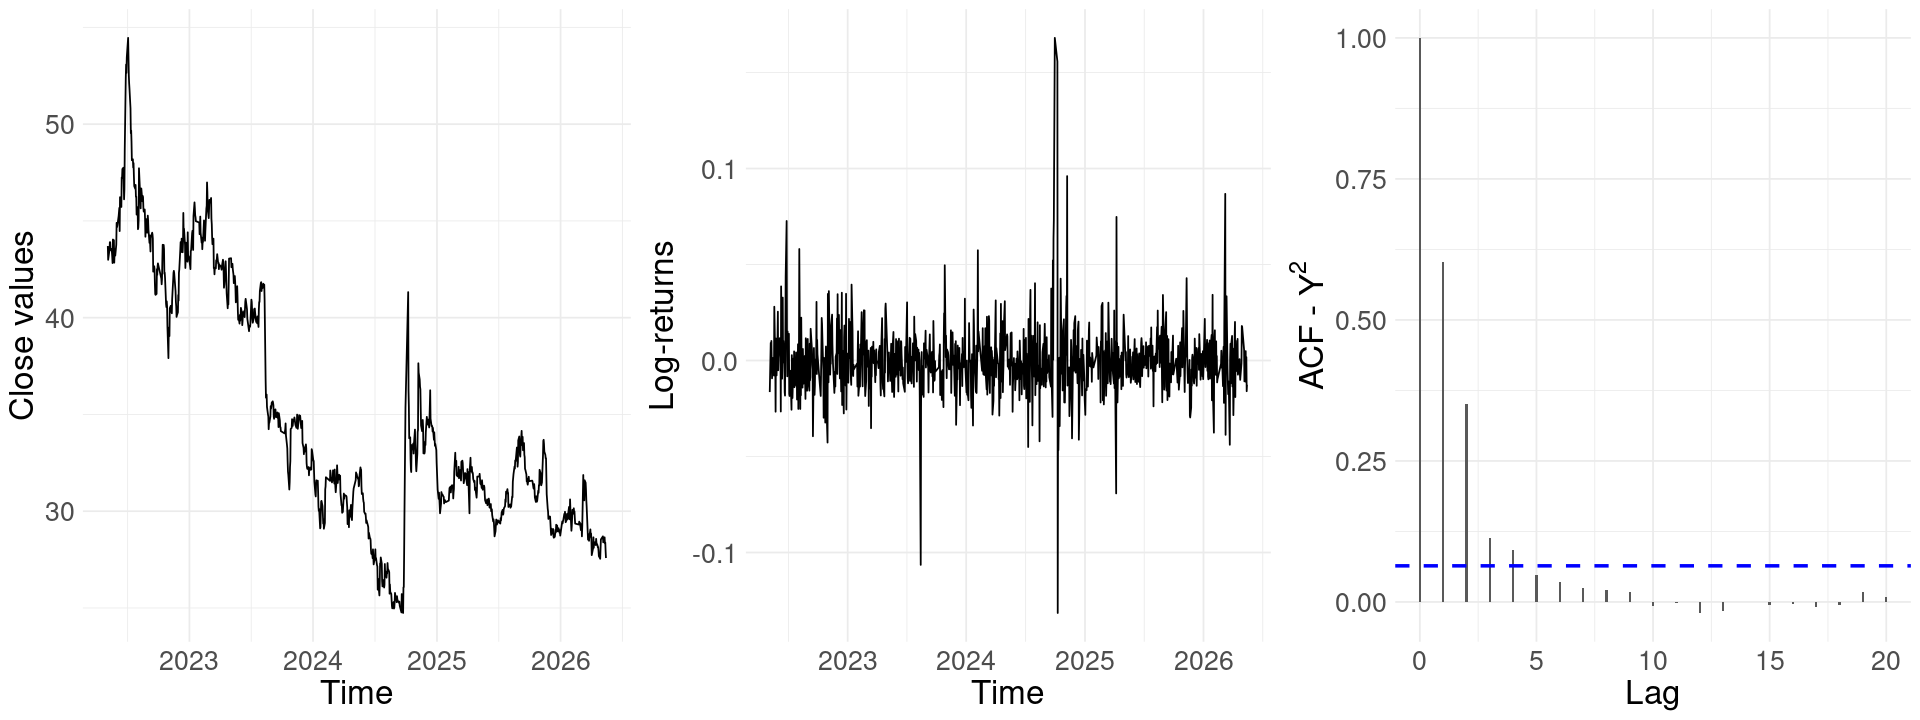

In [44]:
ticker <- "300999.SZ"
start_date <- "2022-05-01"
end_date <- "2026-05-18"

# Fetch the data from Yahoo Finance
# auto.assign = FALSE allows us to save the xts object directly to our variable
cat("Fetching data for:", ticker, "\n")
arawana_data <- getSymbols(ticker, src = "yahoo", 
                           from = start_date, to = end_date, 
                           auto.assign = FALSE)

# Extract the Adjusted Closing prices - account for any corporate actions (like dividends or splits)
adj_close <- Ad(arawana_data)
log_returns <- diff(log(adj_close))

length(log_returns)

# Remove the first NA value (created by the diff function) and any holiday NAs
log_returns <- na.omit(log_returns)
colnames(log_returns) <- "Log_Return"

plot_series <- ggplot()+
    geom_line(aes(x = as.Date( time(adj_close) ), y = adj_close))+
    labs(x = "Time", y = "Close values")

plot_log_returns <- ggplot()+
    geom_line(aes(x = as.Date( time(log_returns) ), y = log_returns))+
    labs(x = "Time", y = "Log-returns")

acf_y2 <- acf(log_returns^2, lag.max = 20, plot = FALSE)
acf_y2$lag <- c(0, acf_y2$lag)
acf_y2$acf <- c(1, acf_y2$acf)

plot_acf <- ggplot()+
    geom_col(aes(x = acf_y2$lag, y = acf_y2$acf), width = 0.1)+
    geom_hline(aes(yintercept = 2/sqrt(T)), linetype = "dashed", color = "blue", linewidth = 1)+
    labs(x = "Lag", y = TeX("ACF - $Y^2$") )

options(repr.plot.width = 20, repr.plot.height = 8)
plot_grid(plot_series, plot_log_returns, plot_acf, nrow = 1)

In [45]:
T <- length(log_returns)
niter <- 10000
burnin <- 5000

set.seed(10)
# -------------------------------- Fit the Bayesian model --------------------------------
start <- Sys.time()
    fit <- fit_garch21_dirichlet(log_returns)
elapsed_sample <- Sys.time() - start
elapsed_sample

Time difference of 23.53835 secs

Time for the divergence metrics computation: 15.18878

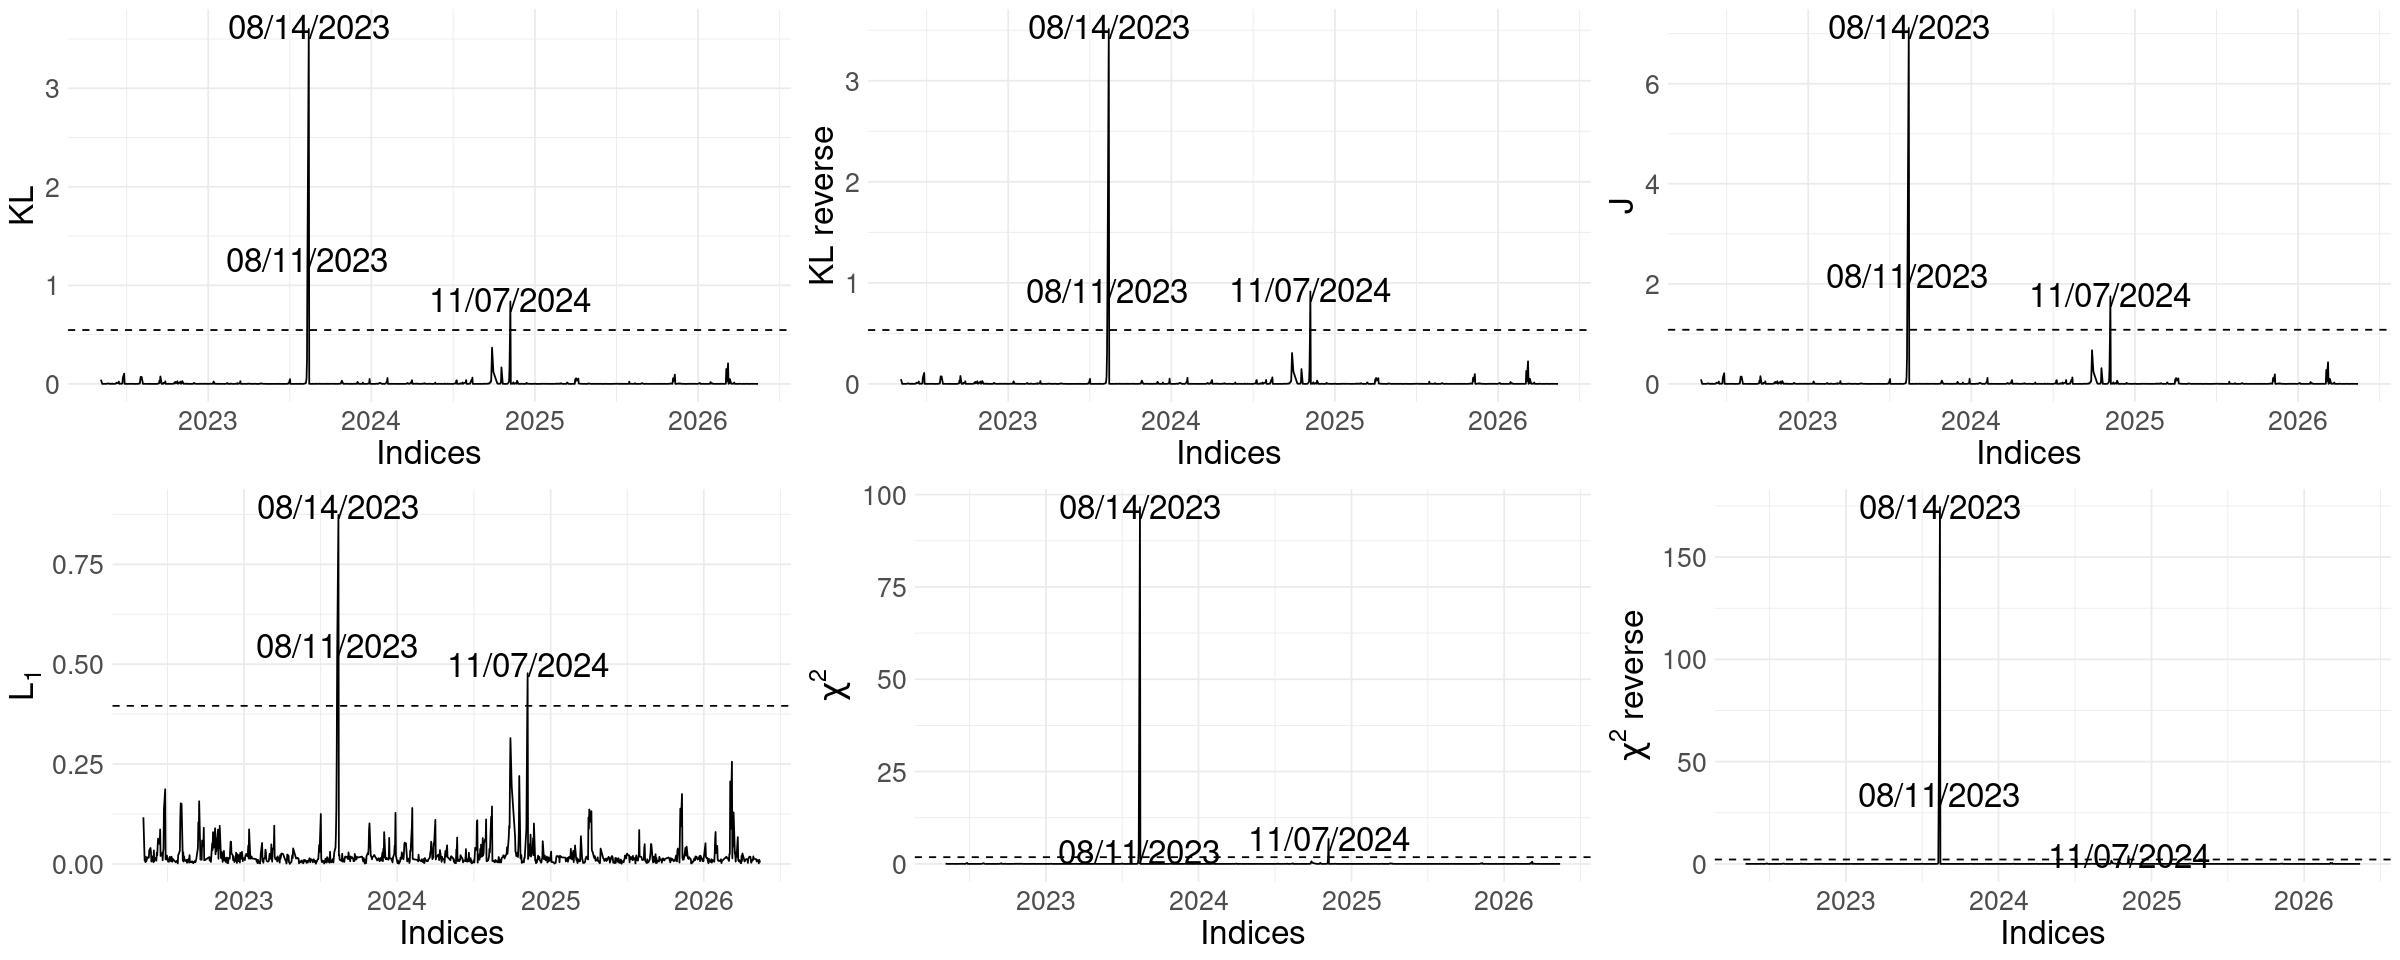

In [52]:
thetas <- cbind(fit$alpha[,1], fit$alpha[,2], fit$alpha[,3], fit$beta)
hs <- fit$h
colnames(thetas) <- c("alpha0", "alpha1", "alpha2", "beta")

start <- Sys.time()
    div <- psi_divergences_cpp_parallel(thetas, hs, log_returns, p = 2, q = 1, k_values = 1:T, verbose = FALSE)
elapsed_div <- Sys.time() - start
# Give the scale of the observations, the divergence for the first observation may be unnecessarily high
# div[1,] <- 0.0

colnames(div) <- c("KL", "KL_rev", "J", "chi2", "chi2_rev", "chi2_sym", "L1", "H", "JS")
div <- as.data.frame(div)
rownames(div) <- as.Date(time(log_returns))

cat("Time for the divergence metrics computation:", elapsed_div)

options(repr.plot.width = 20, repr.plot.height = 8)
plot_divergences(fit, div, q = 0.95)

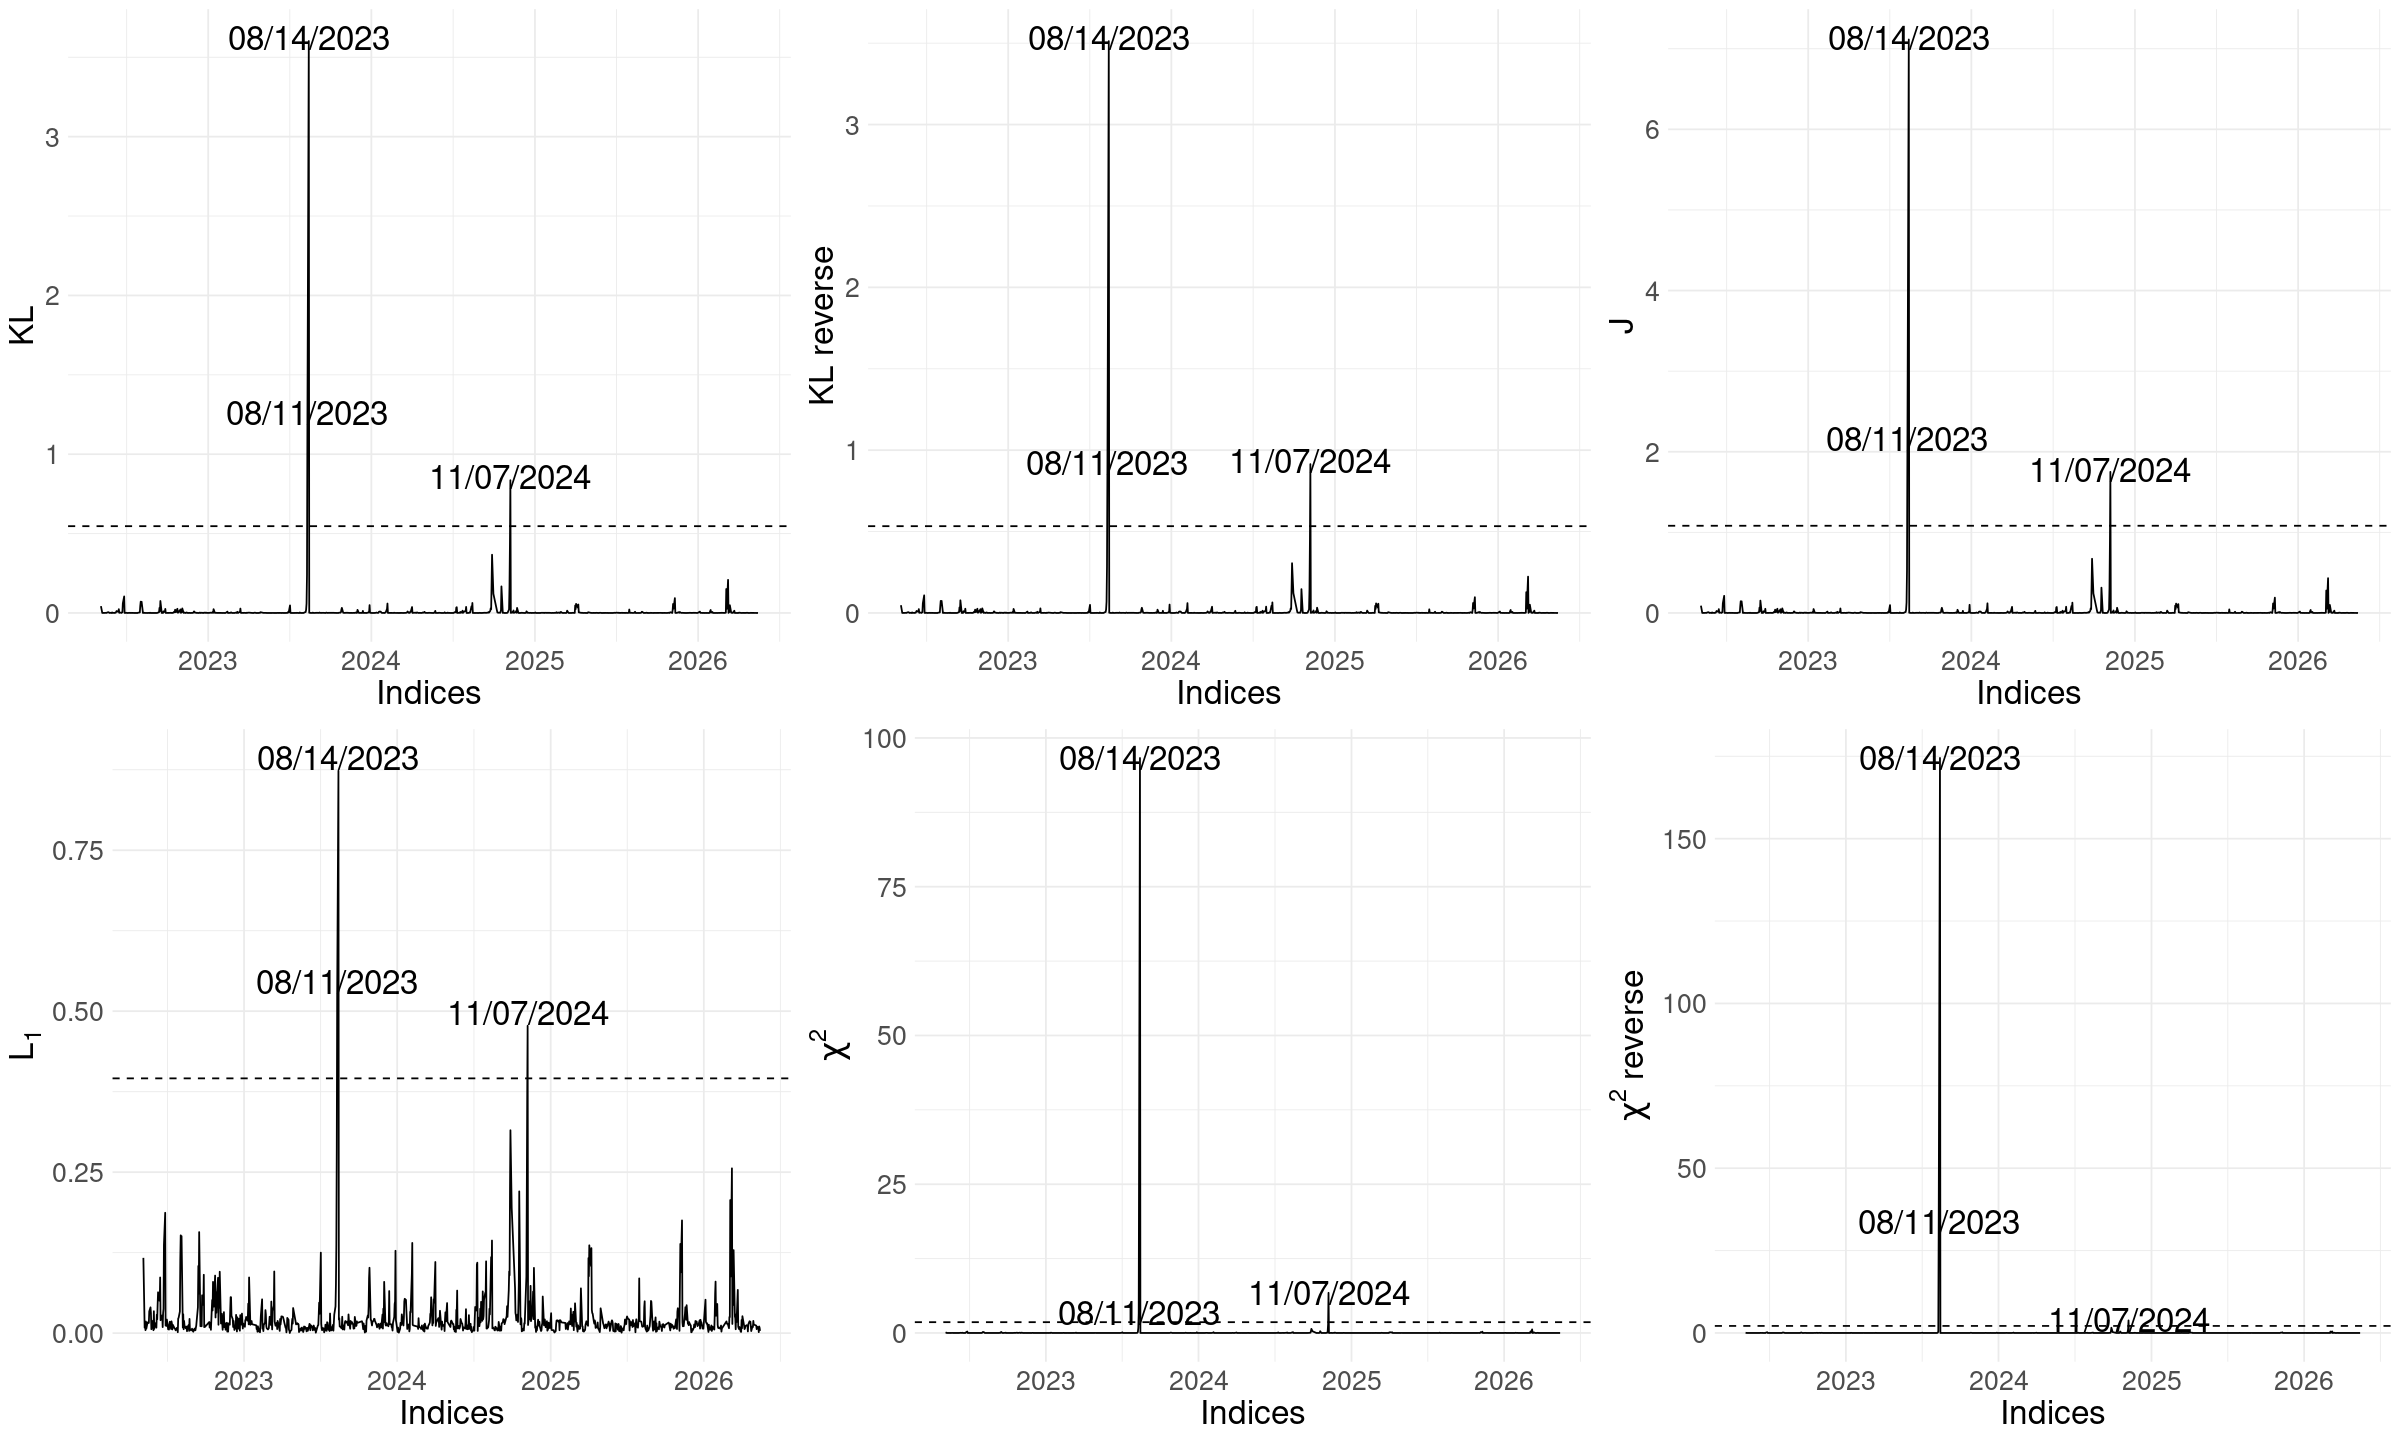

In [56]:
options(repr.plot.width = 20, repr.plot.height = 12)
plot_divergences(fit, div, q = 0.95)